### Lek transition time series

- Load territories data
- Make a stacked area plot showing the transition
- Plot scatter showing territories on both leks

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import math
import re

from pathlib import Path
from datetime import datetime

ModuleNotFoundError: No module named 'geopandas'

In [ ]:
## Output folder for figures
out_dir = Path('output')
out_dir.mkdir(exist_ok=True)

In [3]:
## Load territory data
terr = pd.read_csv('processed_data/territory_data.csv')

## Parse dates
terr['date'] = pd.to_datetime(terr['Date'], format='%Y-%b')

## Pivot to wide so we have one row per timepoint
wide = (terr.pivot_table(index='date', columns='Lek', values='Prop', aggfunc='mean').sort_index()
        .rename(columns={1: 'prop_lek1', 2: 'prop_lek2'}))
wide.head()

Lek,prop_lek1,prop_lek2
date,,
2013-12-01,1.000000,0.000000
2014-02-01,0.744898,0.255102
2014-10-01,0.973684,0.026316
2015-05-01,0.522013,0.477987
2015-11-01,0.720588,0.279412


In [4]:
## Colour palettes
fill_cols = {'Velavadar Lek 1': '#1F6F8B', 'Velavadar Lek 2': '#3FA7A3'}
point_cols = {'Velavadar Lek 1': '#15556B', 'Velavadar Lek 2': '#2B7E7B'}

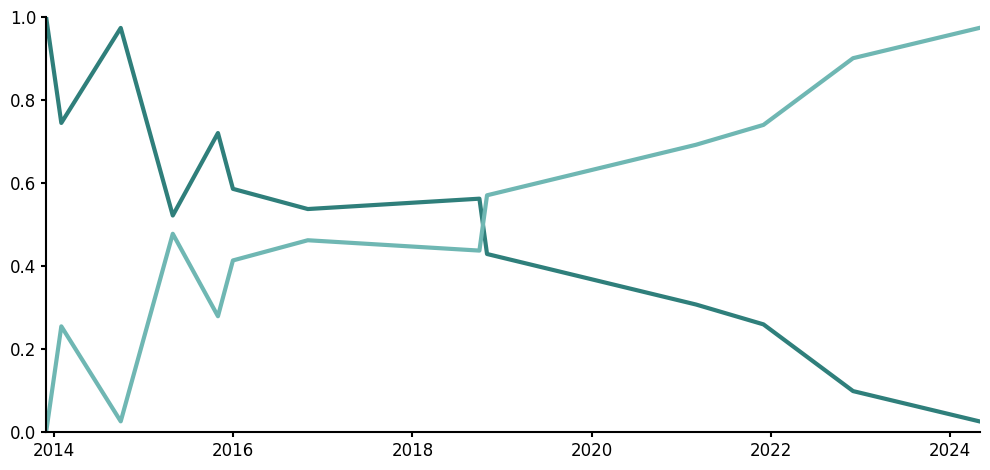

In [12]:
fig, ax = plt.subplots(figsize=(10, 4.8))

## Plot the two sites over time
ax.plot(wide.index, wide['prop_lek1'], color=fill_cols['Velavadar Lek 1'], linewidth=3)
ax.plot(wide.index, wide['prop_lek2'], color=fill_cols['Velavadar Lek 2'], linewidth=3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.set_ylabel('', fontsize=14)
ax.set_xlabel('', fontsize=14)

ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.margins(x=0)
ax.set_ylim(0, 1)
ax.tick_params(axis='both', labelsize=12, width=1.5)

plt.tight_layout()
plt.savefig(out_dir/'transition_data.png', dpi=300)

In [6]:
## Month look-up chart
month_lookup = {'JAN': 1, 'FEB': 2, 'MAR': 3, 'APR': 4, 'MAY': 5, 'JUN': 6, 
                'JUL': 7, 'AUG': 8, 'SEP': 9, 'OCT': 10, 'NOV': 11, 'DEC': 12}

## Parse date from file label
def parse_yyMMM(label):
    '''
    Convert labels like '13DEC' or '14FEB' into a pandas Timestamp
    '''
    m = re.match(r'^(\d{2})([A-Z]{3})$', label.upper())
    if m is None:
        raise ValueError(f'Unrecognized date label: {label}')
        
    yy = int(m.group(1))
    mon = month_lookup[m.group(2)]
    return pd.Timestamp(datetime(2000 + yy, mon, 1))

def read_lek_csv(date_dir, date_label, lek_num):
    '''
    Read a single lek csv
    '''
    f = date_dir / f'{date_label}_LEK{lek_num}.csv'
    if not f.exists():
        return None
    df = pd.read_csv(f)
    
    # Standardize expected columns
    if not set(['latitude', 'longitude']).issubset(df.columns.str.lower()):
        
        # Try case-insensitive mapping
        cols = {c.lower(): c for c in df.columns}
        if 'latitude' in cols and 'longitude' in cols:
            df = df.rename(columns={cols['latitude']: 'latitude', cols['longitude']: 'longitude'})
        else:
            raise ValueError(f'{f} does not contain latitude/longitude columns. Columns: {list(df.columns)}')
    else:
        # If already lower-case, just ensure exact names
        df = df.rename(columns={c: c.lower() for c in df.columns})
    return df[['latitude', 'longitude']].copy()

In [7]:
# Discover date folders
base_dir = Path('rawdata/Velavadar')
data_dirs = sorted([p for p in base_dir.glob('*_COORDINATES') if p.is_dir()])

# Collect per-date point sets
date_records = []
for d in data_dirs:
    date_label = d.name.replace('_COORDINATES', '').upper()
    try:
        date_ts = parse_yyMMM(date_label)
    except Exception as e:
        print(f'Skipping folder (cannot parse date): {d.name} ({e})')
        continue

    df1 = read_lek_csv(d, date_label, 1)
    df2 = read_lek_csv(d, date_label, 2)

    date_records.append({
        'date_label': date_label,
        'date': date_ts,
        'lek1': df1,
        'lek2': df2
    })

if len(date_records) == 0:
    raise RuntimeError(f'No *_COORDINATES folders found under {base_dir.resolve()}')

date_records = sorted(date_records, key=lambda r: r['date'])

In [8]:
## Load roads
roads_gdf = gpd.read_file('rawdata/Velavadar/VelavadarRoads.shp', engine='pyogrio')

## Helper: choose colors from your dicts if present

def _get_col(dct, key, fallback):
    try:
        return dct[key]
    except Exception:
        return fallback

lek1_key = 'Velavadar Lek 1' if 'Velavadar Lek 1' in globals().get('fill_cols', {}) else 'LEK1'
lek2_key = 'Velavadar Lek 2' if 'Velavadar Lek 2' in globals().get('fill_cols', {}) else 'LEK2'

## Fallback colors if your dict keys don't match:
lek1_face = _get_col(globals().get('fill_cols', {}), lek1_key, '#1F77B4')
lek1_edge = _get_col(globals().get('point_cols', globals().get('line_cols', {})), lek1_key, '#1F77B4')

lek2_face = _get_col(globals().get('fill_cols', {}), lek2_key, '#FF7F0E')
lek2_edge = _get_col(globals().get('point_cols', globals().get('line_cols', {})), lek2_key, '#FF7F0E')

## Compute a global bounding box so all panels share the same spatial frame
all_lon = []
all_lat = []

for rec in date_records:
    for df in (rec['lek1'], rec['lek2']):
        if df is not None and len(df) > 0:
            all_lon.extend(df['longitude'].tolist())
            all_lat.extend(df['latitude'].tolist())

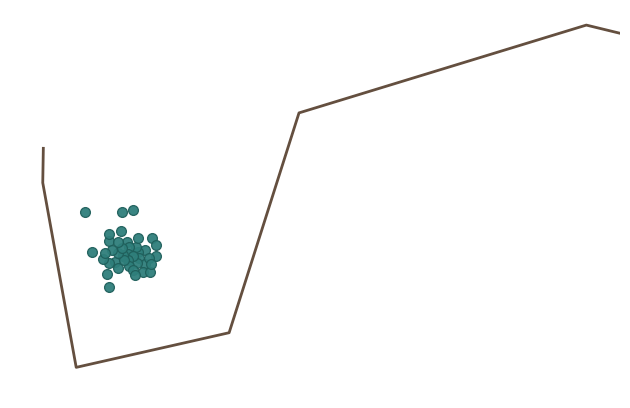

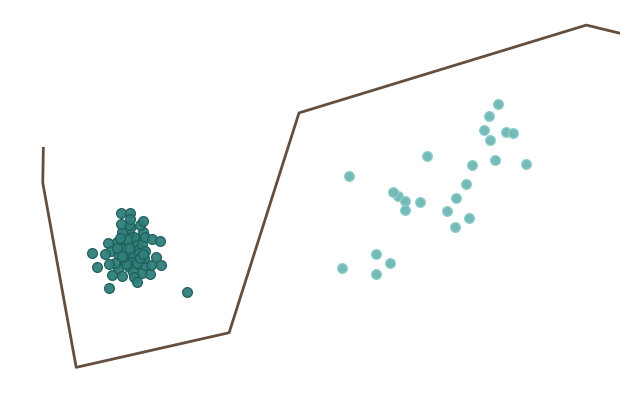

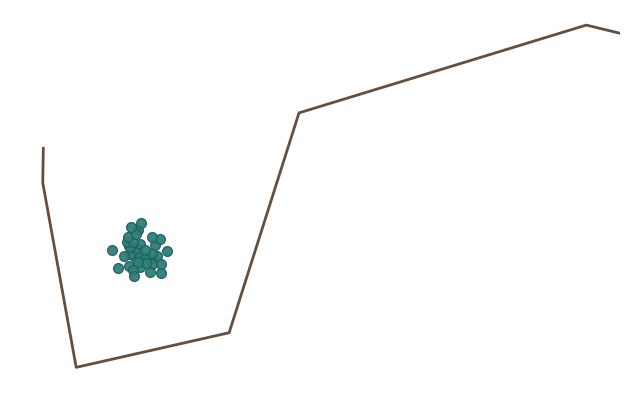

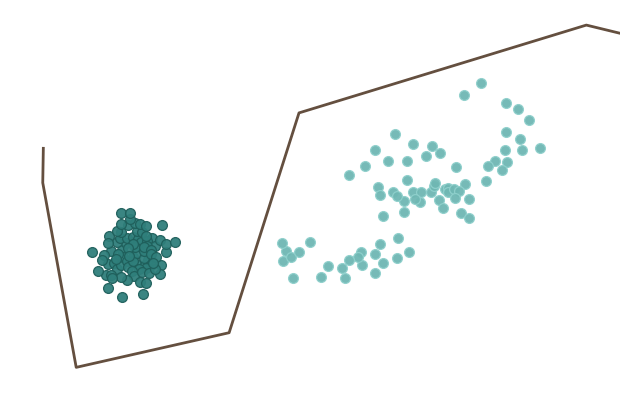

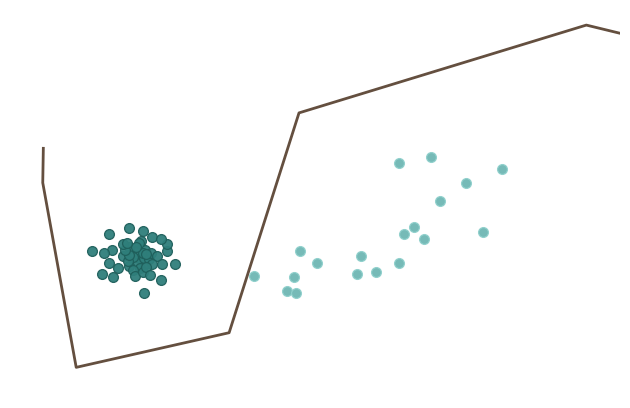

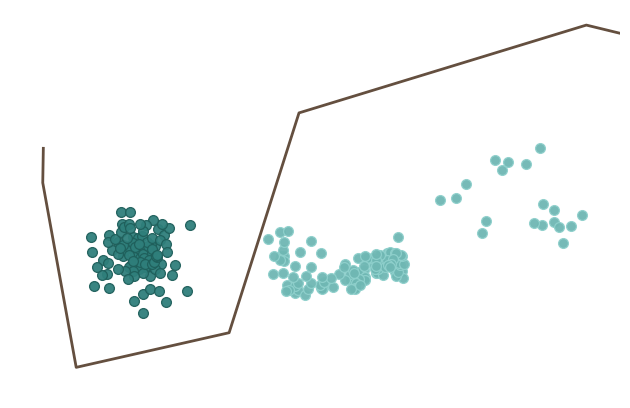

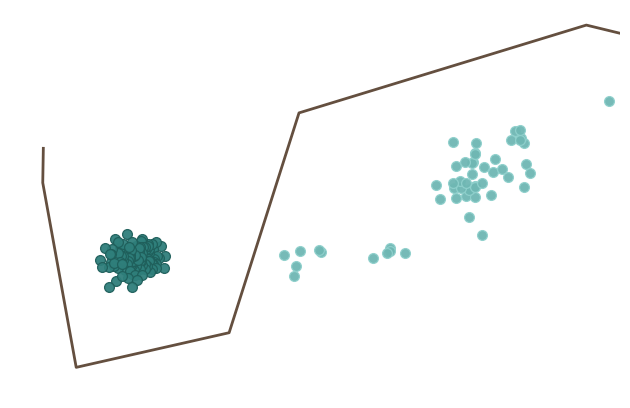

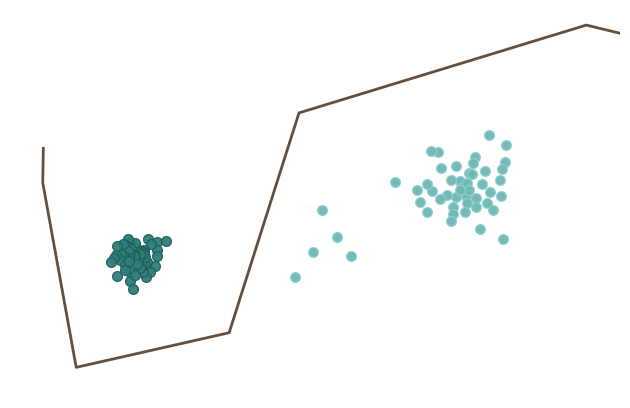

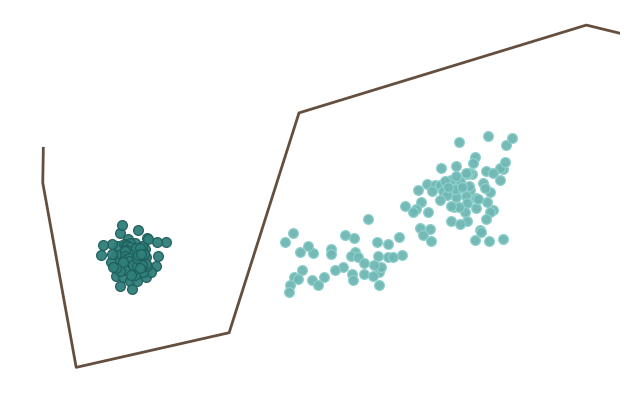

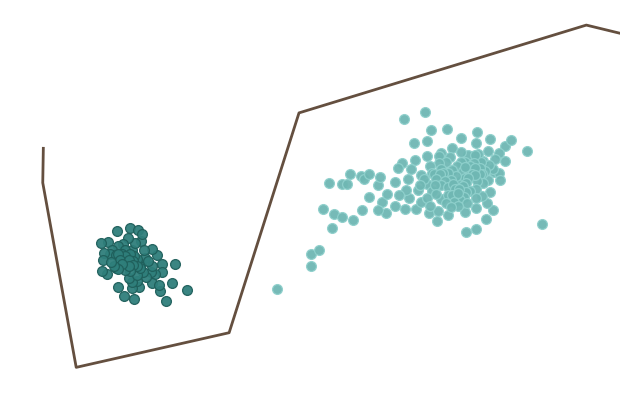

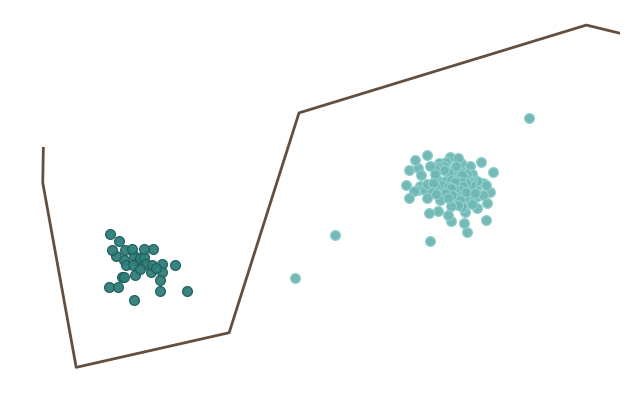

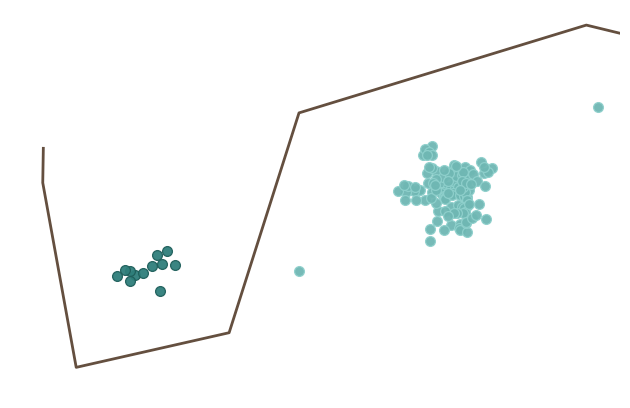

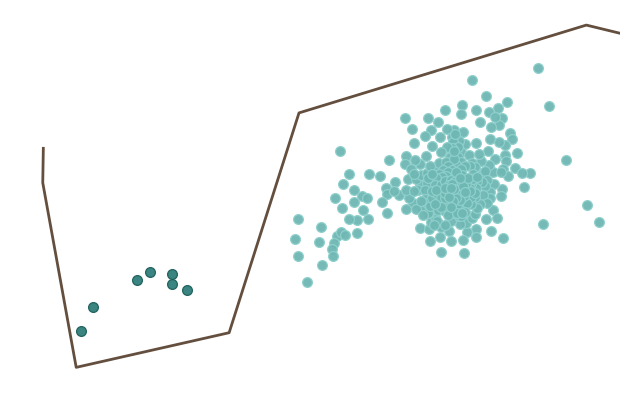

In [9]:
## One figure per date
outdir = Path('output')
outdir.mkdir(exist_ok=True, parents=True)

for rec in date_records:
    fig, ax = plt.subplots(1,1)

    if roads_gdf is not None and not roads_gdf.empty:
        roads_gdf.plot(ax=ax, linewidth=2, color='#3D230F', alpha=0.8, zorder=1)

    if rec['lek1'] is not None and len(rec['lek1']) > 0:
        ax.scatter(rec['lek1']['longitude'], rec['lek1']['latitude'],
                   s=50, facecolor=lek1_face, edgecolor=lek1_edge,
                   linewidth=0.9, alpha=0.95, zorder=3, label='Lek 1')

    if rec['lek2'] is not None and len(rec['lek2']) > 0:
        ax.scatter(rec['lek2']['longitude'], rec['lek2']['latitude'],
                   s=50, facecolor=lek2_face, edgecolor=lek2_edge,
                   linewidth=0.9, alpha=0.95, zorder=4, label='Lek 2')

    ax.set_xlim(72.018,72.04) 
    ax.set_ylim(22.043,22.056)
    ax.set_xticks([])
    ax.set_yticks([])
    
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)

    fig.tight_layout()
    fig.savefig(outdir/f"territories_{rec['date_label']}.png", dpi=300)
    plt.show()